# Principal Component Analysis (PCA) on Pokemon Attributes
## A Professional Data Analytics Exploration

### Executive Summary
This report provides a multi-dimensional analysis of the Pokemon ecosystem.
By leveraging **PCA**, we reduce 6 combat stats to 2 latent dimensions, revealing
universal design templates, power creep trends, and data-driven battle roles.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import plotly.express as px
import plotly.io as pio
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

plt.style.use('ggplot')
sns.set_theme(style='whitegrid', palette='muted')
pio.renderers.default = 'notebook_connected'
pio.templates.default = 'plotly_white'

print('Environment initialized successfully.')


Environment initialized successfully.


## 1. Data Ingestion & Feature Engineering

In [ ]:
df = pd.read_csv('Pokemon.csv')
stats_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

# Safe NaN handling: na=False prevents TypeError on missing Form values
df['IsMega'] = (
    df['Name'].str.contains('Mega ', na=False) |
    df['Form'].str.contains('Mega ', na=False) |
    df['Form'].str.contains('Primal', na=False)
)
df['Form_Type'] = df['IsMega'].map({True: 'Mega/Special', False: 'Base Form'})

# Normalize Type2: replace NaN with empty string
df['Type2'] = df['Type2'].fillna('').str.strip()

print(f'Dataset loaded: {len(df)} entries | Mega/Special: {df["IsMega"].sum()} | Base: {(~df["IsMega"]).sum()}')
display(df.head())


Dataset loaded: 1215 entries | Mega/Special: 50 | Base: 1165


,ID,Name,Form,Type1,Type2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,IsMega,Form_Type
0,1,Bulbasaur,,Grass,Poison,318,45,49,49,65,65,45,1,False,Base Form
1,2,Ivysaur,,Grass,Poison,405,60,62,63,80,80,60,1,False,Base Form
2,3,Venusaur,,Grass,Poison,525,80,82,83,100,100,80,1,False,Base Form
3,4,Charmander,,Fire,,309,39,52,43,60,50,65,1,False,Base Form
4,5,Charmeleon,,Fire,,405,58,64,58,80,65,80,1,False,Base Form


## 2. Global Distribution Statistics
**DA Note**: `Flying` is nearly always a secondary type. Plotting Type 1, Type 2,
and Aggregate distributions separately reveals its true prevalence.


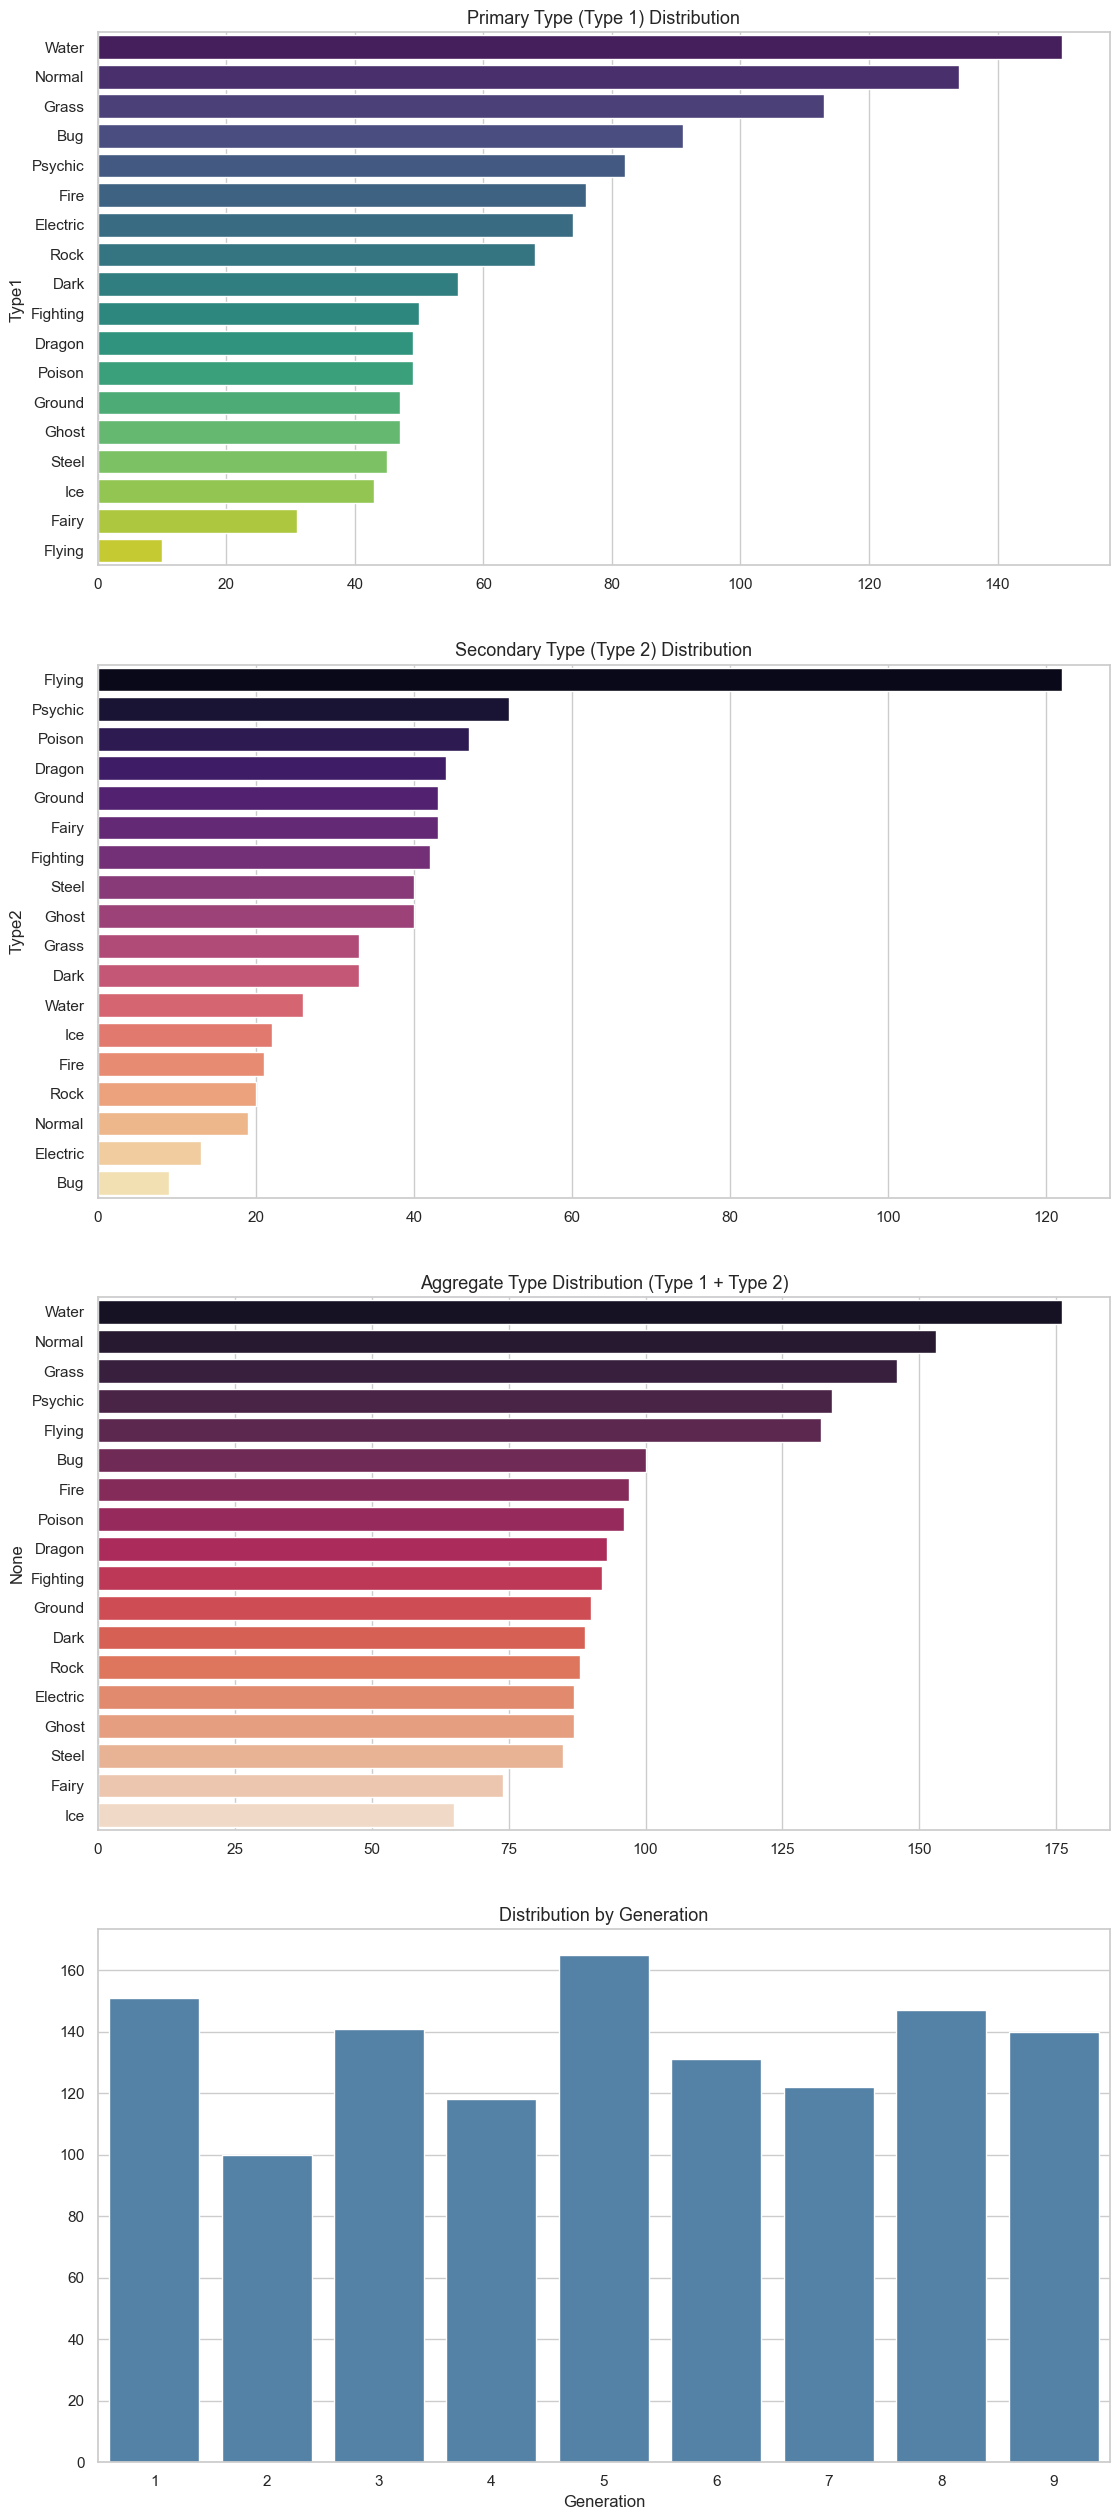

Flying — Type1: 10 | Type2: 122 | Total: 132


In [3]:
fig, axs = plt.subplots(4, 1, figsize=(12, 26))

# Type 1
type1_counts = df['Type1'].value_counts().sort_values(ascending=False)
sns.barplot(x=type1_counts.values, y=type1_counts.index, ax=axs[0],
            hue=type1_counts.index, palette='viridis', legend=False)
axs[0].set_title('Primary Type (Type 1) Distribution', fontsize=13)

# Type 2
type2_series = df[df['Type2'] != '']['Type2']
type2_counts = type2_series.value_counts().sort_values(ascending=False)
sns.barplot(x=type2_counts.values, y=type2_counts.index, ax=axs[1],
            hue=type2_counts.index, palette='magma', legend=False)
axs[1].set_title('Secondary Type (Type 2) Distribution', fontsize=13)

# Aggregate
agg_counts = pd.concat([df['Type1'], type2_series]).value_counts().sort_values(ascending=False)
sns.barplot(x=agg_counts.values, y=agg_counts.index, ax=axs[2],
            hue=agg_counts.index, palette='rocket', legend=False)
axs[2].set_title('Aggregate Type Distribution (Type 1 + Type 2)', fontsize=13)

# Generation
gen_counts = df['Generation'].value_counts().sort_index()
sns.barplot(x=gen_counts.index, y=gen_counts.values, ax=axs[3], color='steelblue')
axs[3].set_title('Distribution by Generation', fontsize=13)

plt.tight_layout(pad=3.0)
plt.show()

print(f"Flying — Type1: {type1_counts.get('Flying', 0)} | Type2: {type2_counts.get('Flying', 0)} | Total: {agg_counts.get('Flying', 0)}")


## 3. Competitive Leaderboards (Top 10)

In [4]:
print('--- Top 10 Pokemon by Overall Total Stat ---')
display(df.nlargest(10, 'Total')[['Name', 'Type1', 'Type2', 'Total', 'Form_Type']])

for stat in stats_cols:
    print(f'\n--- Top 10 by {stat} ---')
    display(df.nlargest(10, stat)[['Name', 'Type1', stat, 'Form_Type']])


--- Top 10 Pokemon by Overall Total Stat ---


,Name,Type1,Type2,Total,Form_Type
1054,Eternatus,Poison,Dragon,1125,Base Form
688,Mewtwo,Psychic,Fighting,780,Mega/Special
689,Mewtwo,Psychic,,780,Mega/Special
717,Rayquaza,Dragon,Flying,780,Mega/Special
715,Kyogre,Water,,770,Mega/Special
716,Groudon,Ground,Fire,770,Mega/Special
918,Necrozma,Psychic,Dragon,754,Base Form
509,Arceus,Normal,,720,Base Form
828,Zygarde,Dragon,Ground,708,Base Form
668,Kyurem,Dragon,Ice,700,Base Form



--- Top 10 by HP ---


,Name,Type1,HP,Form_Type
241,Blissey,Normal,255,Base Form
1054,Eternatus,Poison,255,Base Form
112,Chansey,Normal,250,Base Form
914,Guzzlord,Dark,223,Base Form
828,Zygarde,Dragon,216,Base Form
1060,Regidrago,Dragon,200,Base Form
201,Wobbuffet,Psychic,190,Base Form
320,Wailord,Water,170,Base Form
1155,Cetitan,Ice,170,Base Form
612,Alomomola,Water,165,Base Form



--- Top 10 by Attack ---


...

,Name,Type1,Sp. Atk,Form_Type
689,Mewtwo,Psychic,194,Mega/Special
389,Deoxys,Psychic,180,Base Form
715,Kyogre,Water,180,Mega/Special
717,Rayquaza,Dragon,180,Mega/Special
681,Alakazam,Psychic,175,Mega/Special
911,Xurkitree,Electric,173,Base Form
668,Kyurem,Dragon,170,Base Form
683,Gengar,Ghost,170,Mega/Special
804,Hoopa,Psychic,170,Base Form
918,Necrozma,Psychic,167,Base Form



--- Top 10 by Sp. Def ---


,Name,Type1,Sp. Def,Form_Type
1054,Eternatus,Poison,250,Base Form
212,Shuckle,Bug,230,Base Form
380,Regice,Ice,200,Base Form
390,Deoxys,Psychic,160,Base Form
715,Kyogre,Water,160,Mega/Special
248,Lugia,Psychic,154,Base Form
249,Ho-oh,Fire,154,Base Form
745,Florges,Fairy,154,Base Form
381,Registeel,Steel,150,Base Form
485,Probopass,Rock,150,Base Form



--- Top 10 by Speed ---


,Name,Type1,Speed,Form_Type
1059,Regieleki,Electric,200,Base Form
391,Deoxys,Psychic,180,Base Form
290,Ninjask,Bug,160,Base Form
910,Pheromosa,Bug,151,Base Form
100,Electrode,Electric,150,Base Form
388,Deoxys,Psychic,150,Base Form
389,Deoxys,Psychic,150,Base Form
681,Alakazam,Psychic,150,Mega/Special
687,Aerodactyl,Rock,150,Mega/Special
937,Electrode,Electric,150,Base Form


## 4. PCA Modeling & Dimensionality Reduction

Explained Variance: PC1=45.7%, PC2=18.2%
Cumulative: 63.8%


,PC1,PC2
HP,0.413724,-0.135478
Attack,0.434994,-0.005007
Defense,0.394981,-0.571768
Sp. Atk,0.428850,0.336536
Sp. Def,0.452486,-0.177461
Speed,0.308133,0.714110


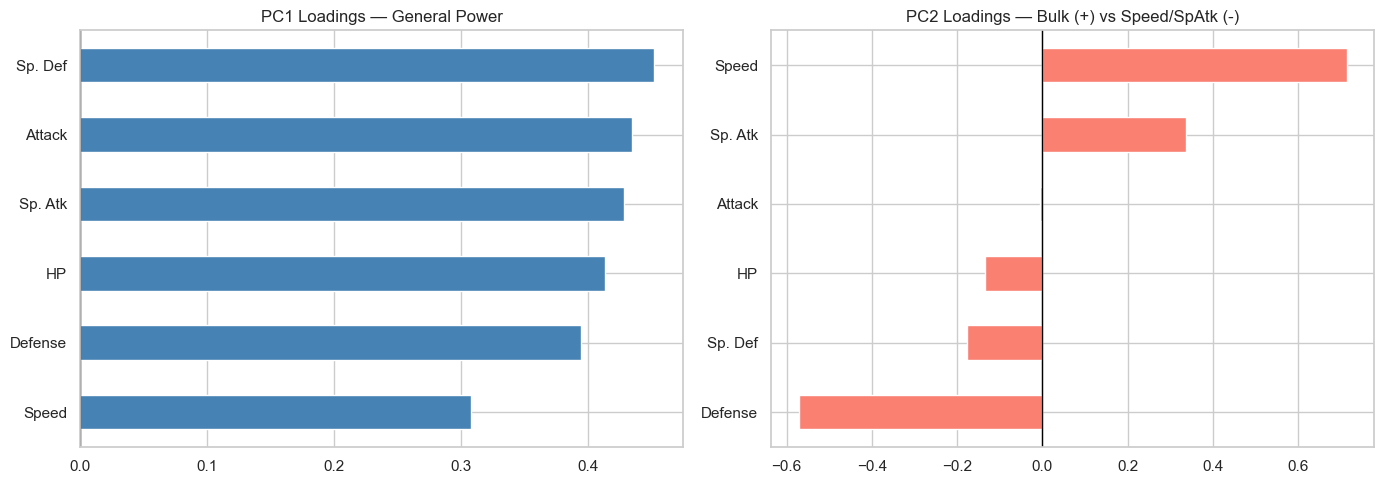

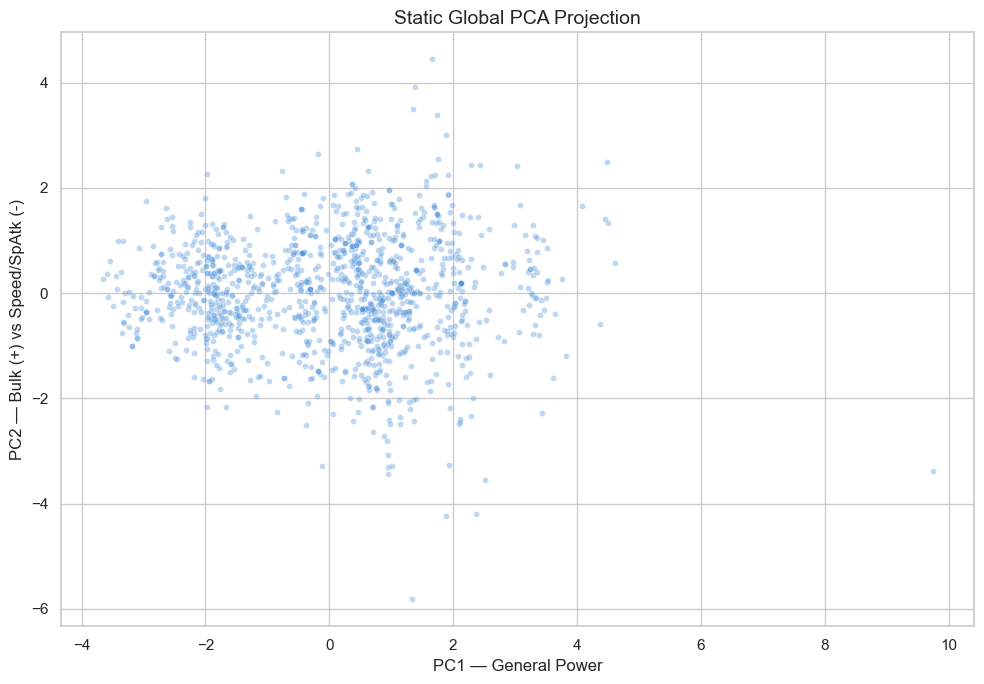

In [5]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df[stats_cols])

pca = PCA(n_components=2)
pcs = pca.fit_transform(x_scaled)

pca_df = pd.DataFrame(pcs, columns=['PC1', 'PC2'])
extra_cols = df[['Name', 'Type1', 'Type2', 'Generation', 'Total', 'Form_Type'] + stats_cols].reset_index(drop=True)
pca_df = pd.concat([pca_df, extra_cols], axis=1)

loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=stats_cols)

print(f"Explained Variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
print(f"Cumulative: {sum(pca.explained_variance_ratio_):.1%}")
display(loadings)

# Loading bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
loadings['PC1'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].axvline(0, color='black', lw=1)
axes[0].set_title('PC1 Loadings — General Power')
loadings['PC2'].sort_values().plot(kind='barh', ax=axes[1], color='salmon')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('PC2 Loadings — Bulk (+) vs Speed/SpAtk (-)')
plt.tight_layout()
plt.show()

# Static Global Scatter
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', alpha=0.35, s=18, color='#4a90d9')
plt.title('Static Global PCA Projection', fontsize=14)
plt.xlabel('PC1 — General Power')
plt.ylabel('PC2 — Bulk (+) vs Speed/SpAtk (-)')
plt.tight_layout()
plt.show()


## 5. Type Highlight Analysis
Static facet grid and interactive Plotly version.

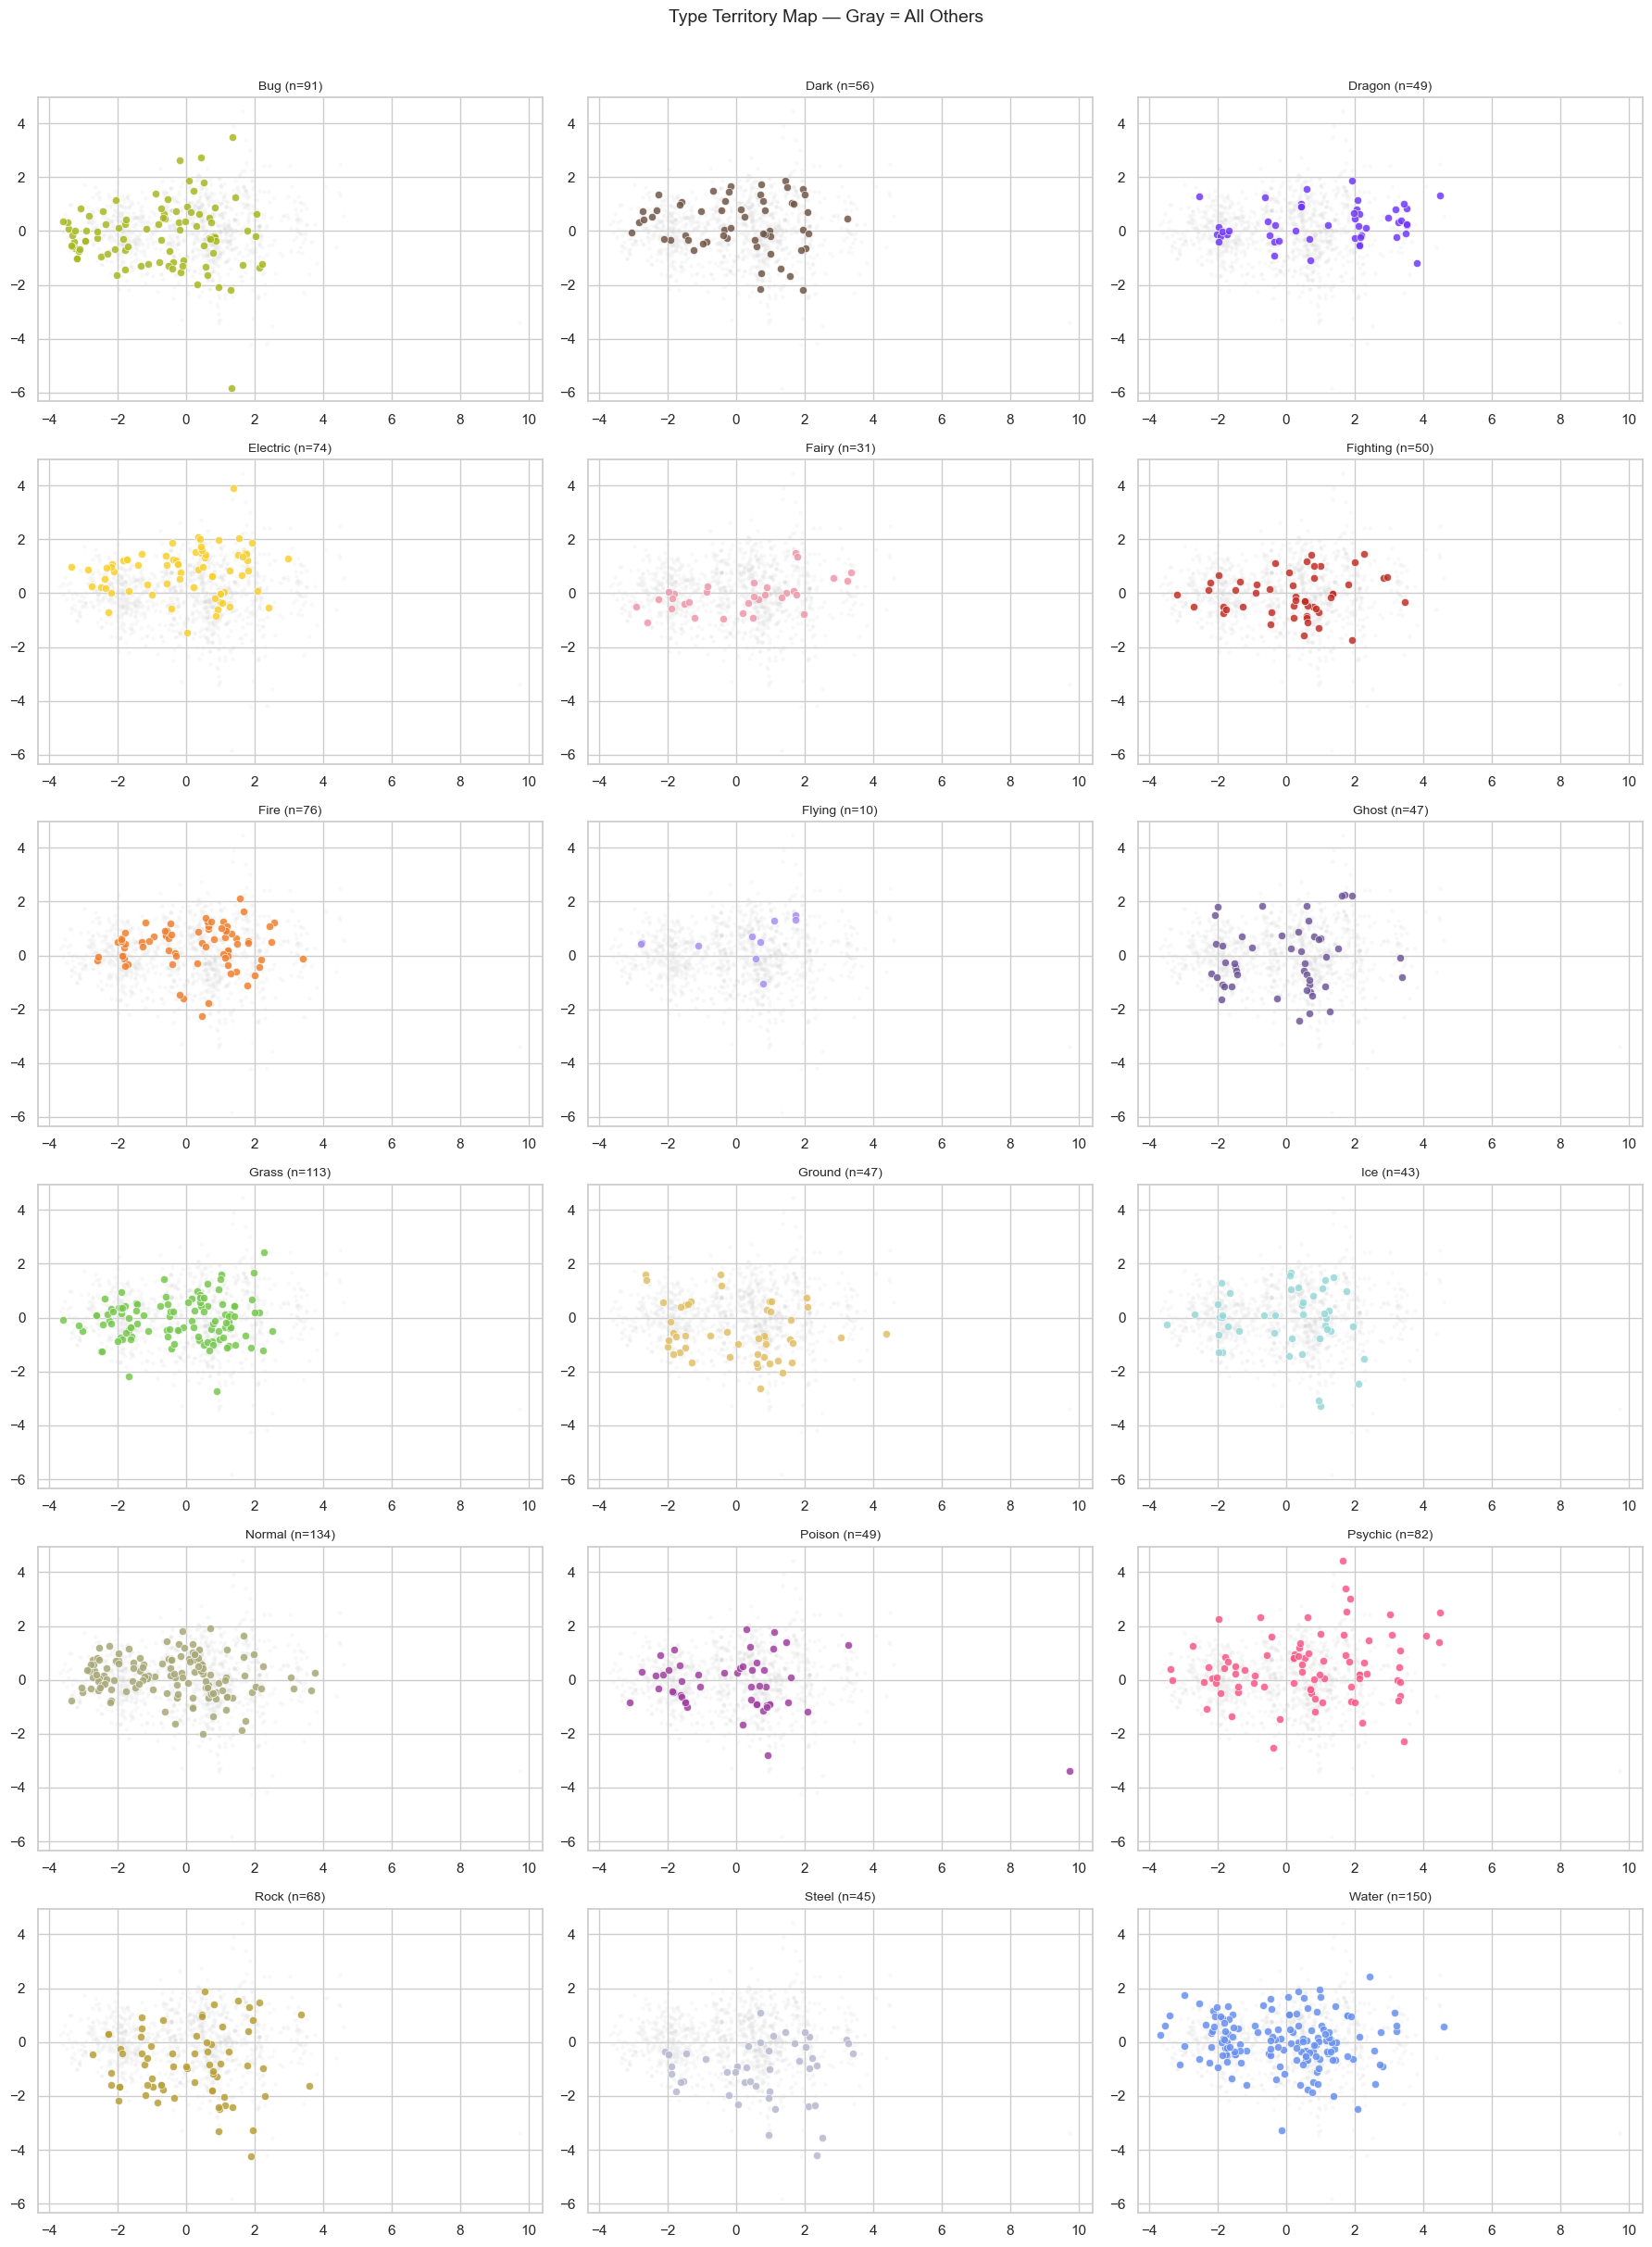

In [6]:
type_colors = {
    'Grass': '#78C850', 'Fire': '#F08030', 'Water': '#6890F0', 'Bug': '#A8B820',
    'Normal': '#A8A878', 'Poison': '#A040A0', 'Electric': '#F8D030', 'Ground': '#E0C068',
    'Fairy': '#EE99AC', 'Fighting': '#C03028', 'Psychic': '#F85888', 'Rock': '#B8A038',
    'Ghost': '#705898', 'Ice': '#98D8D8', 'Dragon': '#7038F8', 'Dark': '#705848',
    'Steel': '#B8B8D0', 'Flying': '#A890F0'
}

unique_types = sorted(pca_df['Type1'].unique())
n_cols = 3
n_rows = int(np.ceil(len(unique_types) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, t in enumerate(unique_types):
    ax = axes[i]
    sns.scatterplot(data=pca_df, x='PC1', y='PC2', color='lightgrey', alpha=0.15, ax=ax, s=10)
    tdata = pca_df[pca_df['Type1'] == t]
    sns.scatterplot(data=tdata, x='PC1', y='PC2', color=type_colors.get(t, '#888'), alpha=0.85, ax=ax, s=35)
    ax.set_title(f'{t} (n={len(tdata)})', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Type Territory Map — Gray = All Others', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [7]:
fig_facet = px.scatter(
    pca_df, x='PC1', y='PC2',
    color='Type1', facet_col='Type1', facet_col_wrap=6,
    hover_name='Name', color_discrete_map=type_colors,
    title='Interactive Type Highlights (hover to inspect)',
    height=1100, template='plotly_white'
)
fig_facet.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))
fig_facet.update_traces(marker=dict(size=5, opacity=0.8))
fig_facet.update_layout(showlegend=False)
fig_facet.show()


## 6. Interactive Centroids & Global Population Map

In [8]:
centroids = pca_df.groupby('Type1')[['PC1', 'PC2']].mean().reset_index()

fig_centroids = px.scatter(
    centroids, x='PC1', y='PC2', color='Type1', text='Type1',
    color_discrete_map=type_colors,
    title='Type Centroids — Center of Mass per Type',
    template='plotly_white', height=700
)
fig_centroids.update_traces(textposition='top center', marker=dict(size=14, line=dict(width=1, color='black')))
fig_centroids.update_layout(showlegend=False)
fig_centroids.show()

fig_map = px.scatter(
    pca_df, x='PC1', y='PC2', color='Type1', hover_name='Name',
    hover_data={'Type2': True, 'Total': True, 'Form_Type': True, 'PC1': ':.2f', 'PC2': ':.2f'},
    color_discrete_map=type_colors,
    title='Full Population Interactive PCA Map',
    height=900, template='plotly_white'
)
fig_map.update_traces(marker=dict(size=6, opacity=0.75))
fig_map.show()


## 7. Power Creep Analysis: Base Forms vs Special Forms

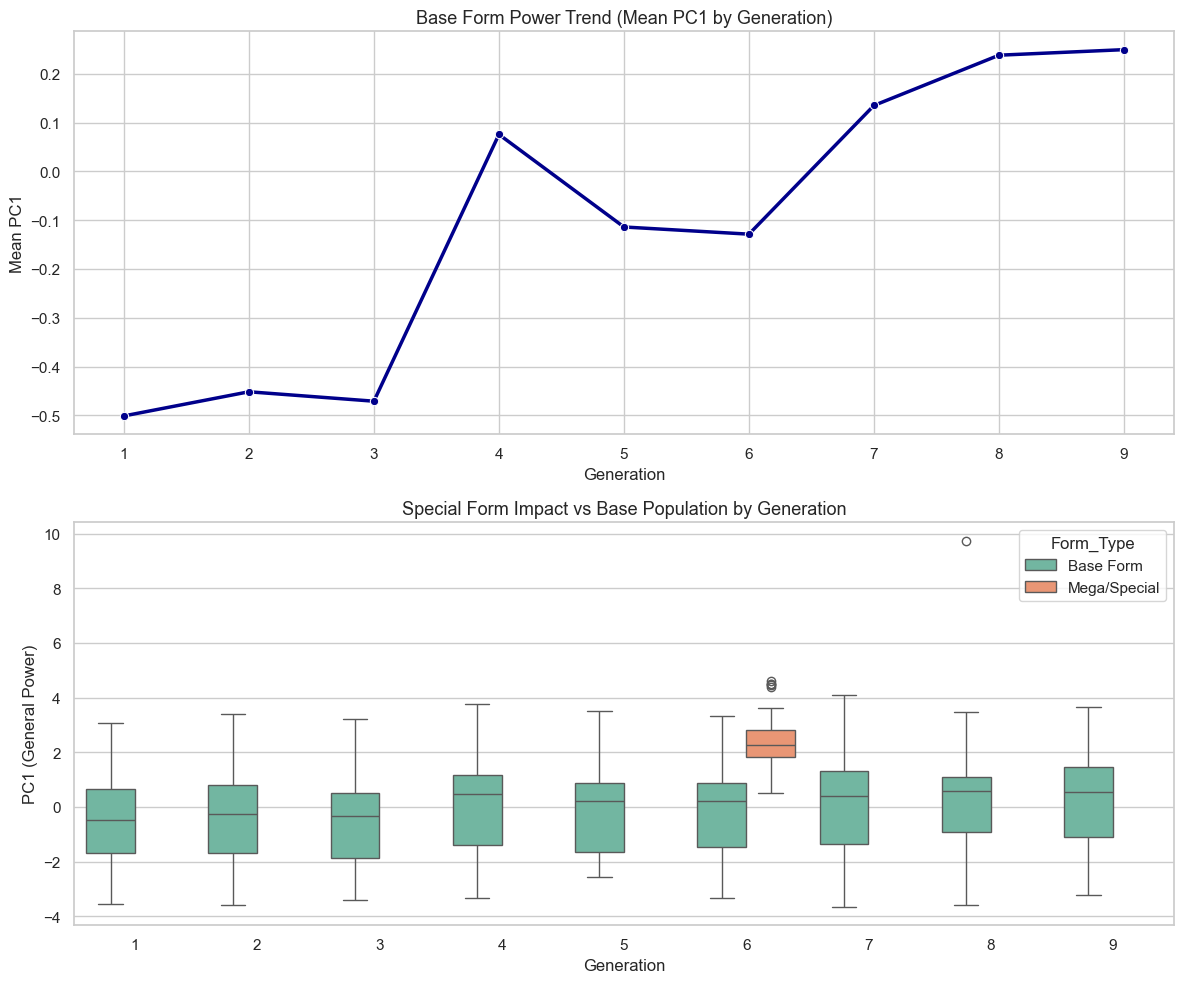

In [9]:
base_only = pca_df[pca_df['Form_Type'] == 'Base Form'].copy()
gen_trend = base_only.groupby('Generation')['PC1'].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

sns.lineplot(data=gen_trend, x='Generation', y='PC1', marker='o', ax=ax1,
             color='darkblue', linewidth=2.5)
ax1.set_title('Base Form Power Trend (Mean PC1 by Generation)', fontsize=13)
ax1.set_ylabel('Mean PC1')
ax1.set_xticks(range(1, int(gen_trend['Generation'].max()) + 1))

sns.boxplot(data=pca_df, x='Generation', y='PC1', hue='Form_Type', ax=ax2, palette='Set2')
ax2.set_title('Special Form Impact vs Base Population by Generation', fontsize=13)
ax2.set_ylabel('PC1 (General Power)')

plt.tight_layout()
plt.show()
